In [7]:
from google.colab import files
uploaded = files.upload()

Saving corporate_ai_adoption_dataset.csv to corporate_ai_adoption_dataset (2).csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("corporate_ai_adoption_dataset.csv")


In [13]:
print(df.head())
print(df.info())
print(df.describe())

print(df.shape)
print(df.isnull().sum())


df = df.drop_duplicates()


print("Total Companies :", len(df))


   company_id            industry        country  year  ai_adoption_level  \
0  CORP-06613  Financial Services          China  2029             0.4987   
1  CORP-01597         Agriculture        Germany  2032             0.5213   
2  CORP-02938              Energy  United States  2024             0.6147   
3  CORP-05207              Retail        Germany  2021             0.4401   
4  CORP-07489          Technology  United States  2024             0.1918   

   ai_investment_usd  automation_rate  cost_savings  revenue_impact  \
0           11747237           0.4119       3519354         2751513   
1            1267219           0.4580        295244          304776   
2            8168951           0.5821       2472329         5170304   
3            1234261           0.2880        512061         -233448   
4            5000645           0.1906       2122064         2110644   

   productivity_gain  employee_ai_training_hours  ai_maturity_score  \
0             0.3924                   

In [14]:
df["AI_Success"] = np.where(df["ai_maturity_score"] >= 6, 1, 0)

success_percentage = df["AI_Success"].mean() * 100
print("AI Success Percentage :", success_percentage)


AI Success Percentage : 54.618500000000004


In [15]:
cols = [
    "ai_investment_usd",
    "automation_rate",
    "cost_savings",
    "revenue_impact",
    "productivity_gain",
    "employee_ai_training_hours",
    "ai_maturity_score",
]

for col in cols:
    print("\n", col)
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Std :", df[col].std())
    print("Quartiles :")
    print(df[col].quantile([0.25,0.50,0.75]))



 ai_investment_usd
Mean : 4870558.43886
Median : 3991639.5
Std : 3679703.7744748364
Quartiles :
0.25    2221252.25
0.50    3991639.50
0.75    6517931.25
Name: ai_investment_usd, dtype: float64

 automation_rate
Mean : 0.4367225504999999
Median : 0.42815000000000003
Std : 0.2170306507464829
Quartiles :
0.25    0.27350
0.50    0.42815
0.75    0.59200
Name: automation_rate, dtype: float64

 cost_savings
Mean : 2128917.872325
Median : 1354826.5
Std : 2415688.900859011
Quartiles :
0.25     599354.75
0.50    1354826.50
0.75    2745080.50
Name: cost_savings, dtype: float64

 revenue_impact
Mean : 2591989.184135
Median : 1408779.0
Std : 3972751.2251483877
Quartiles :
0.25     533980.5
0.50    1408779.0
0.75    3132148.5
Name: revenue_impact, dtype: float64

 productivity_gain
Mean : 0.39529702899999997
Median : 0.3926
Std : 0.19562343136855134
Quartiles :
0.25    0.2493
0.50    0.3926
0.75    0.5393
Name: productivity_gain, dtype: float64

 employee_ai_training_hours
Mean : 76.75533400000002


In [16]:
# Probability of successful AI adoption
p_success = (df["AI_Success"] == 1).mean()
print("Probability of Success :", p_success)

# Probability by industry
industry_prob = df.groupby("industry")["AI_Success"].mean()
print(industry_prob)

# Probability by country
country_prob = df.groupby("country")["AI_Success"].mean()
print(country_prob)

# Probability of success if investment > median
median_inv = df["ai_investment_usd"].median()

high_inv = df[df["ai_investment_usd"] > median_inv]
print(
    "P(Success | High Investment) =",
    (high_inv["AI_Success"] == 1).mean()
    )

Probability of Success : 0.546185
industry
Agriculture           0.548621
Education             0.537572
Energy                0.549432
Financial Services    0.548573
Healthcare            0.548822
Logistics             0.544473
Manufacturing         0.549056
Retail                0.548184
Technology            0.539340
Telecom               0.547353
Name: AI_Success, dtype: float64
country
Australia         0.517450
Brazil            0.423276
Canada            0.549140
China             0.549908
France            0.516269
Germany           0.536347
India             0.491194
Japan             0.510159
Netherlands       0.515377
Singapore         0.563921
South Korea       0.516370
Sweden            0.542766
UAE               0.482215
United Kingdom    0.568947
United States     0.602596
Name: AI_Success, dtype: float64
P(Success | High Investment) = 0.73542


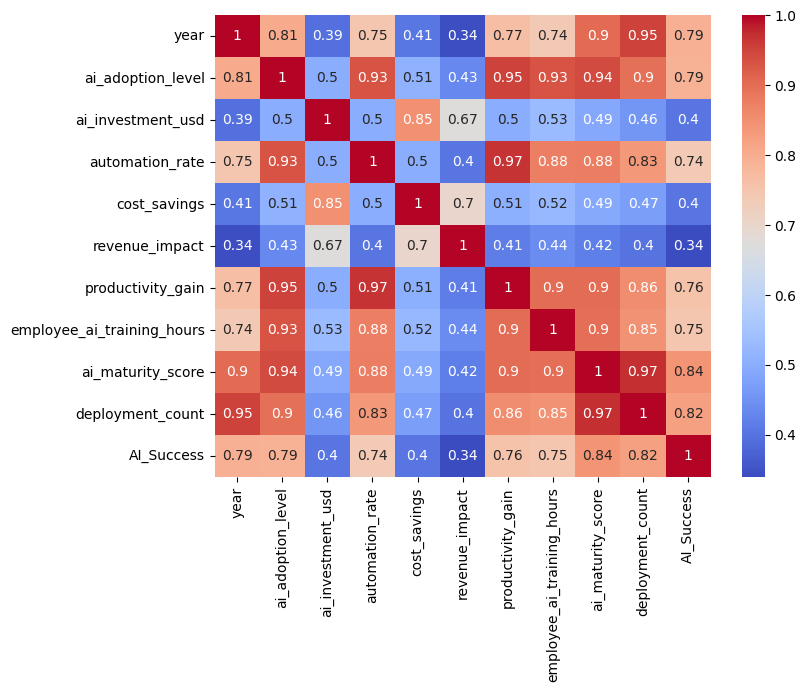

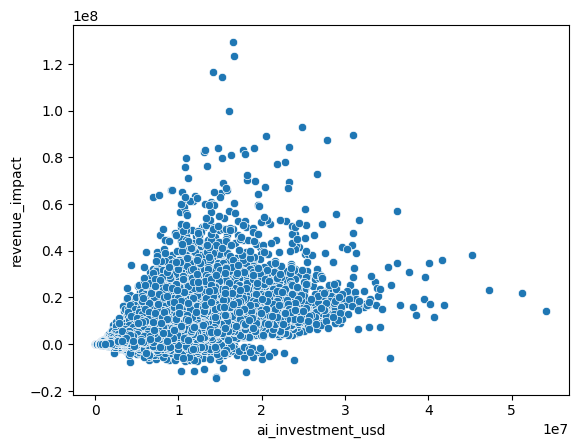

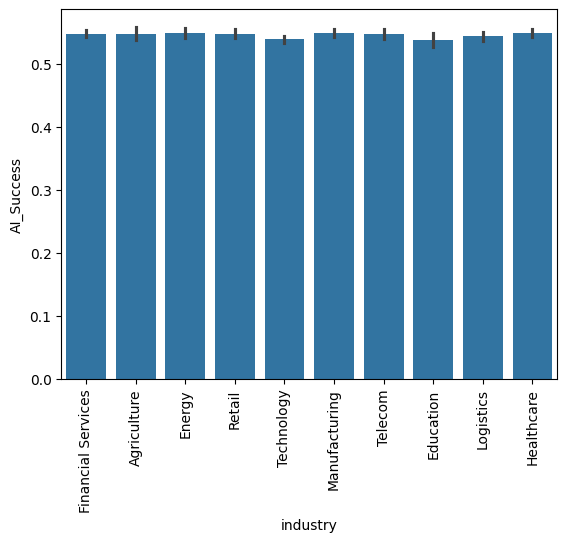

In [17]:

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()


sns.scatterplot(
    x="ai_investment_usd",
    y="revenue_impact",
    data=df
)
plt.show()


sns.barplot(
    x="industry",
    y="AI_Success",
    data=df
)
plt.xticks(rotation=90)
plt.show()

In [18]:
from scipy.stats import ttest_ind

success = df[df["AI_Success"] == 1]["ai_investment_usd"]
failure = df[df["AI_Success"] == 0]["ai_investment_usd"]

t_stat, p_value = ttest_ind(success, failure)

print("T-Statistic :", t_stat)
print("P-Value :", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")


T-Statistic : 197.1417300615694
P-Value : 0.0
Reject Null Hypothesis


In [19]:
df["Investment_Level"] = np.where(
    df["ai_investment_usd"] >
    df["ai_investment_usd"].median(),
    "High Investment",
    "Low Investment"
)

print(df.groupby("Investment_Level")["AI_Success"].mean())


Investment_Level
High Investment    0.73542
Low Investment     0.35695
Name: AI_Success, dtype: float64


In [20]:
print("Top Industries")
print(df.groupby("industry")["AI_Success"].mean().sort_values(ascending=False))

print("Top Countries")
print(df.groupby("country")["AI_Success"].mean().sort_values(ascending=False))

Top Industries
industry
Energy                0.549432
Manufacturing         0.549056
Healthcare            0.548822
Agriculture           0.548621
Financial Services    0.548573
Retail                0.548184
Telecom               0.547353
Logistics             0.544473
Technology            0.539340
Education             0.537572
Name: AI_Success, dtype: float64
Top Countries
country
United States     0.602596
United Kingdom    0.568947
Singapore         0.563921
China             0.549908
Canada            0.549140
Sweden            0.542766
Germany           0.536347
Australia         0.517450
South Korea       0.516370
France            0.516269
Netherlands       0.515377
Japan             0.510159
India             0.491194
UAE               0.482215
Brazil            0.423276
Name: AI_Success, dtype: float64
